# 14 · 패턴: 의존성 스위퍼 (안전한 것은 올리고, 나머지는 넘긴다)

**패턴:** 의존성 스위퍼(dependency sweeper).

> "안전(patch + CVE 없음), 주의(minor), 고위험(major 또는 고심각도 CVE)으로 트리아지한다.
> 안전한 항목은 최소 버전 승급을 적용하고 검증기를 돌린다. 주의·고위험은 사람 확인 필요로
> 표시한다." 사람 게이트: major 승급, 고심각도 CVE, 거부목록 패키지.

**문제 설정** — 사람이 지켜보지 않는 스위퍼는 위험한 의존성 변경을 자동 병합해서는 안 된다. 순진한 정책 — "빌드가 초록이니 병합한다" — 은 major 승급과 CVE 대응 변경까지 자동으로 밀어 넣는다. **테스트가 통과했다는 사실은 API 파손이나 공급망 위험을 잡아 주지 않기 때문이다.** 스위퍼는 병합을 결정하기 전에 semver 와 CVE 로 먼저 등급을 매기고, 검증을 거친 patch 수준·CVE 없음 업데이트만 자동으로 적용해야 한다.

**측정 대상** — 의존성 업데이트 시나리오 집합 위에서 두 정책의 **오병합률(false auto merge rate)** 을 잰다. 위험한 업데이트를 사람 확인 없이 병합해 버린 비율이다. 순진한 "초록이면 병합" 정책과 의존성 스위퍼 라우터를 비교하고, 여기에 **라우터가 진짜로 안전한 패치를 여전히 몇 퍼센트나 자동 적용하는지**를 함께 본다.


============================================= 의존성 스위퍼 ==============================================


*업데이트마다 semver 와 CVE 로 등급을 매긴다: 안전한 패치는 자동 적용, 나머지는 사람에게*

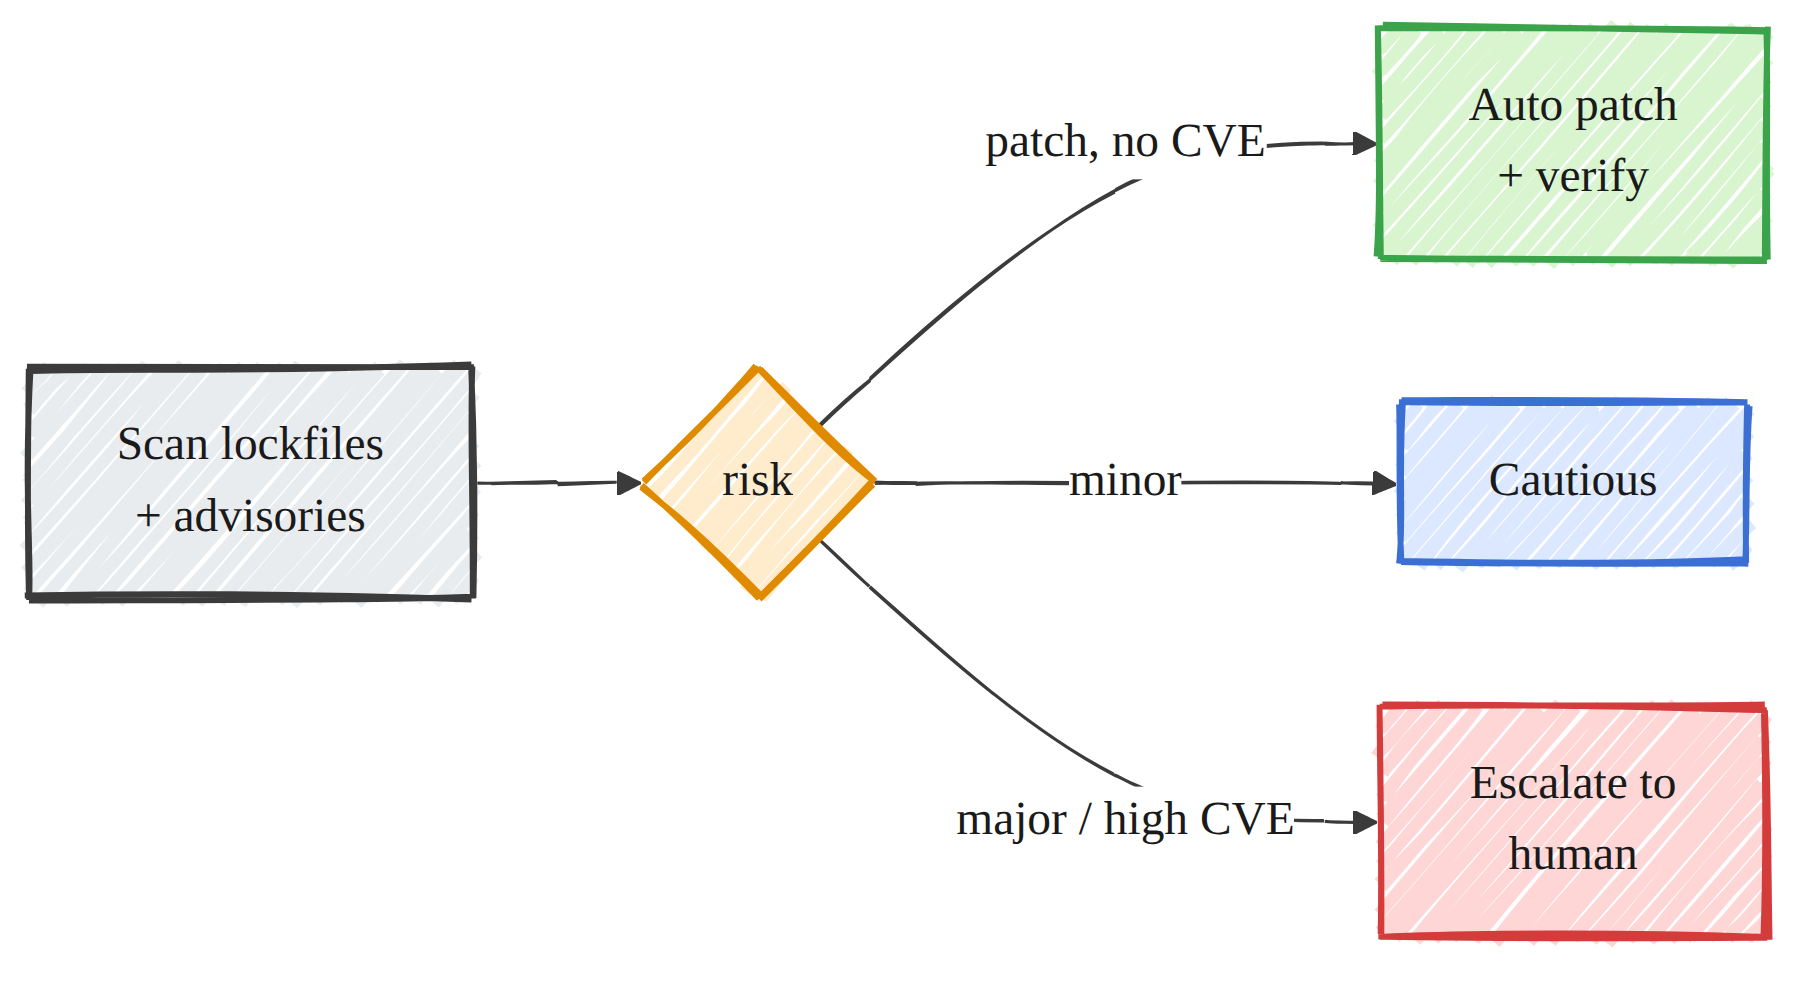

  의존성 업데이트:                  60
  진짜로 위험한 것 (major·minor / 고심각도 CVE / 거부목록): 48

--------------------------------------------- 업데이트 표본 ----------------------------------------------
  pkg           cur    new     tier   severity  denylisted  green  risky
  ------------  -----  ------  -----  --------  ----------  -----  -----
  django        3.5.8  3.5.10  patch  none      True        True   True 
  numpy         2.1.5  3.0.0   major  none      False       True   True 
  cryptography  1.3.6  1.4.0   minor  none      True        True   True 
  flask         1.2.9  2.0.0   major  low       False       True   True 
  cryptography  2.2.4  2.3.0   minor  none      True        True   True 
  cryptography  2.3.6  2.4.0   minor  none      True        True   True 


In [1]:
import os
import sys
import random

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, plotting, runlog, runtime

# ── 이 노트북은 모델을 한 번도 호출하지 않는다 ─────────────────────
# 업데이트 큐는 전부 합성 데이터이고 두 정책은 순수 함수다. 그래도 어느
# 환경에서 남긴 기록인지는 남겨 둔다. 백엔드가 없어도 결과가 달라지지
# 않으므로 판별 실패는 삼킨다.
try:
    rt = runtime.bootstrap(verbose=False)
    ENV_PROVIDER, ENV_MODEL = rt.llm.provider, rt.llm.model
except Exception:
    ENV_PROVIDER, ENV_MODEL = "none", "none"

show.head("의존성 스위퍼")
show.diagram("dependency_sweeper", "업데이트마다 semver 와 CVE 로 등급을 매긴다: 안전한 패치는 자동 적용, 나머지는 사람에게")

# 거부목록: 암호·인증·HTTP·ORM 처럼 침해나 파손의 폭발 반경이 큰 패키지다.
# semver 등급이 아무리 낮아도 사람이 본다. 09번의 경로 거부목록과 같은 성격의
# 목록이며, "중요한 패키지" 가 아니라 "틀렸을 때 되돌리기 비싼 패키지" 목록이다.
DENYLIST_PKGS = {"cryptography", "pyjwt", "requests", "django", "sqlalchemy"}  # 보안·인프라 민감
rng = random.Random(5)      # seed 고정: 두 정책이 반드시 같은 큐를 본다


def bump_tier(cur, new):
    """버전 문자열 두 개를 비교해 semver 등급을 돌려준다. 위에서부터 검사한다."""
    a, b = [int(x) for x in cur.split(".")], [int(x) for x in new.split(".")]
    if b[0] != a[0]:
        return "major"
    if b[1] != a[1]:
        return "minor"
    return "patch"


def make_update():
    pkg = rng.choice(["numpy", "pandas", "flask", "cryptography", "pyjwt", "requests", "click",
                      "rich", "pydantic", "django", "sqlalchemy", "tqdm", "pytest", "urllib3"])
    major, minor, patch = rng.randint(1, 5), rng.randint(0, 9), rng.randint(0, 9)
    cur = f"{major}.{minor}.{patch}"
    # patch 를 두 번 넣어 2:1:1 로 뽑는다. 실제 큐도 작은 승급에 몰려 있다.
    tier = rng.choice(["patch", "patch", "minor", "major"])
    if tier == "patch":
        new = f"{major}.{minor}.{patch + rng.randint(1, 3)}"
    elif tier == "minor":
        new = f"{major}.{minor + rng.randint(1, 3)}.0"
    else:
        new = f"{major + rng.randint(1, 2)}.0.0"
    has_cve = rng.random() < 0.25          # 네 건에 한 건꼴로 권고가 붙은 큐
    severity = rng.choice(["low", "medium", "high"]) if has_cve else "none"
    # 정책: patch 이고, 고심각도 CVE 가 없고, 거부목록이 아닐 때만 자동으로 안전하다
    # ⚠️ 함정: 여기서 risky 는 정책 그 자체다. 정답 라벨이 정책 정의에서 유도되므로
    #    라벨 잡음이 없고 라우팅 논리를 깨끗하게 시험할 수 있다. 대신 이 설정에서
    #    나온 오병합 수치를 "실제 저장소에서도 같다" 로 옮겨 읽으면 안 된다.
    #    현실의 semver·CVE 메타데이터는 이렇게 깨끗하지 않다.
    risky = (bump_tier(cur, new) != "patch") or (severity == "high") or (pkg in DENYLIST_PKGS)
    # 승급 후의 CI 결과를 흉내 낸다. 작은 승급일수록 초록이 잦지만, 어느 등급도
    # 0 이나 1 이 아니다 — 초록이 안전의 증명이 아니라는 사실이 여기 들어 있다.
    # ⚠️ 함정: 이 세 확률은 측정치가 아니라 모형 가정이다. 결론("초록은 필요조건일
    #    뿐이다")은 이 값들에 의존하지 않지만, major 의 0.5 같은 수치를 실제
    #    생태계의 통계처럼 인용하면 안 된다.
    green = rng.random() < {"patch": 0.95, "minor": 0.8, "major": 0.5}[bump_tier(cur, new)]
    return {"pkg": pkg, "cur": cur, "new": new, "tier": bump_tier(cur, new),
            "severity": severity, "denylisted": pkg in DENYLIST_PKGS, "green": green, "risky": risky}


updates = [make_update() for _ in range(60)]     # 60건: 등급·심각도 조합이 골고루 나오는 최소 크기
n = len(updates)
n_risky = sum(u["risky"] for u in updates)
show.kv("의존성 업데이트", n)
show.kv("진짜로 위험한 것 (major·minor / 고심각도 CVE / 거부목록)", n_risky)
show.table([{k: u[k] for k in ["pkg", "cur", "new", "tier", "severity", "denylisted", "green", "risky"]} for u in updates[:6]],
           columns=["pkg", "cur", "new", "tier", "severity", "denylisted", "green", "risky"], title="업데이트 표본")

## 두 정책

- **순진한 정책** — CI 가 초록인 업데이트는 무엇이든 자동 병합한다. semver 등급도, CVE 도, 거부목록도 보지 않는다.
- **스위퍼 라우터** — patch 수준이고, 고심각도 CVE 가 없고, 거부목록 패키지가 아닌 업데이트만, 그리고 빌드가 초록일 때만 자동 적용한다(격리된 곳에서 검증한다). 그 밖의 전부는 에스컬레이션한다.


In [2]:
def naive_merge(u):
    # 순진한 정책: 축이 하나뿐이다. 빌드가 초록이면 병합한다.
    # 등급도 CVE 도 거부목록도 읽지 않는다.
    return u["green"]


def sweeper_merge(u):
    # 스위퍼 라우터: 성질이 다른 세 검사를 AND 로 묶고, 그 위에 초록을 전제조건으로
    # 얹는다. 어디까지 바뀌는가(등급), 알려진 취약점이 있는가(CVE), 폭발 반경이
    # 큰 패키지인가(거부목록). 하나라도 걸리면 그 검사가 단독으로 거부권을 쓴다.
    return (u["tier"] == "patch") and (u["severity"] != "high") and (not u["denylisted"]) and u["green"]


def evaluate(policy):
    merged = [u for u in updates if policy(u)]
    false_merge = sum(1 for u in merged if u["risky"])            # 위험한데 자동 병합했다
    safe_applied = sum(1 for u in merged if not u["risky"])       # 안전한데 자동 적용했다
    safe_total = sum(1 for u in updates if not u["risky"])
    # ⚠️ 함정: 오병합률의 분모는 '위험한 업데이트 수'(n_risky)이지 전체 건수가 아니다.
    #    전체로 나누면 위험한 것이 드문 큐에서는 어떤 정책이든 좋아 보인다.
    # ⚠️ 함정: safe_apply_rate 를 표에서 빼고 보면, 전부 사람에게 넘기는 자명한
    #    정책이 오병합 0 으로 만점을 받는다. 두 열은 반드시 함께 읽어야 한다.
    return {
        "auto_merged": len(merged),
        "false_auto_merge": false_merge,
        "false_auto_merge_rate": false_merge / n_risky if n_risky else 0.0,
        "safe_apply_rate": safe_applied / safe_total if safe_total else 0.0,
    }

M_naive = evaluate(naive_merge)
M_sweeper = evaluate(sweeper_merge)
show.head("결과")
show.table([
    {"policy": "naive (green=merge)", **{k: round(v, 3) if isinstance(v, float) else v for k, v in M_naive.items()}},
    {"policy": "sweeper router", **{k: round(v, 3) if isinstance(v, float) else v for k, v in M_sweeper.items()}},
], columns=["policy", "auto_merged", "false_auto_merge", "false_auto_merge_rate", "safe_apply_rate"],
   title="false_auto_merge (자동 병합된 위험한 업데이트)가 핵심 지표다. 낮을수록 좋다")


================================================ 결과 ================================================

----------------------- false_auto_merge (자동 병합된 위험한 업데이트)가 핵심 지표다. 낮을수록 좋다 ------------------------
  policy               auto_merged  false_auto_merge  false_auto_merge_rate  safe_apply_rate
  -------------------  -----------  ----------------  ---------------------  ---------------
  naive (green=merge)  52           40                0.833                  1.0            
  sweeper router       12           0                 0.0                    1.0            


## 그래프


  오병합률: 스위퍼 vs 순진한 정책
    baseline : 0.8333
    treatment: 0.0000
    delta    : -0.8333  (-100.0 percent)  [down, improvement]


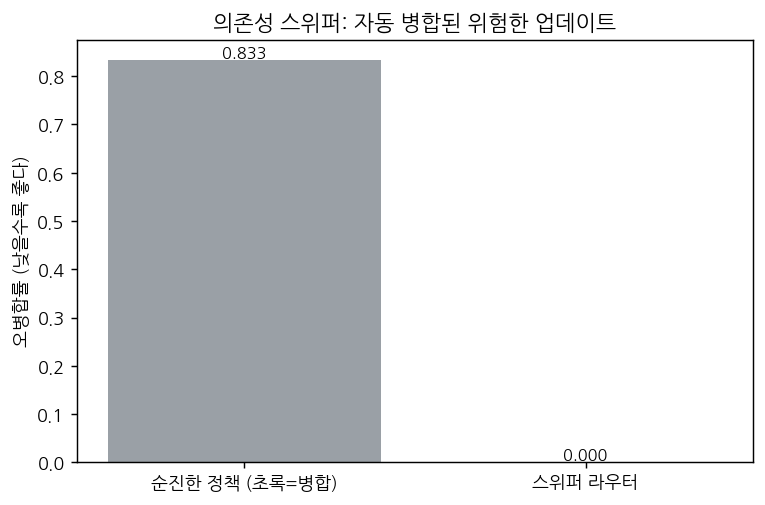

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/14_false_merge.png


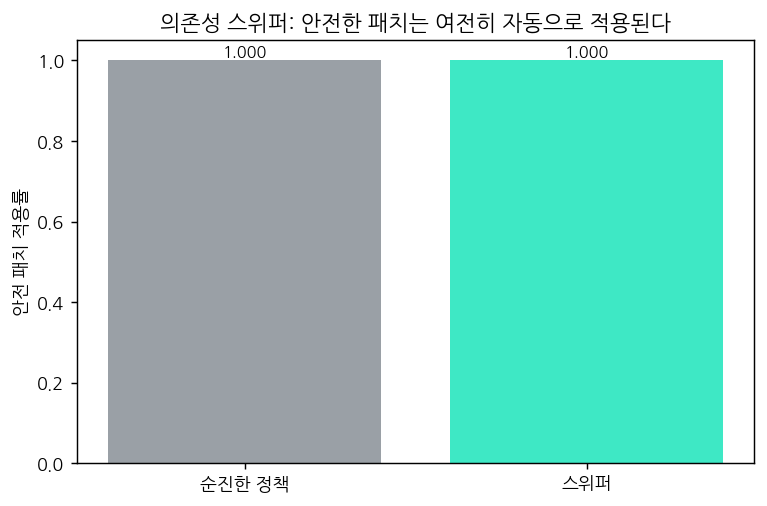

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/14_safe_apply.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/14_dependency_sweeper.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (dependency-sweeper: report-only, ~0 tokens)


{'run_id': '2026-08-19T07:34:58Z',
 'pattern': 'dependency-sweeper',
 'duration_s': 0.0,
 'items_found': 60,
 'actions_taken': 12,
 'escalations': 48,
 'tokens_estimate': 0,
 'outcome': 'report-only'}

In [3]:
# ── 두 장으로 나눠 그린다 ─────────────────────────────────────────
# 첫 장이 헤드라인(오병합률), 둘째 장이 그 0 이 '아무것도 안 해서' 얻어진
# 것이 아님을 확인시켜 주는 안전 패치 적용률이다. 한 장만 그리면 자동화를
# 포기한 라우터와 구분되지 않는다.
show.compare("오병합률: 스위퍼 vs 순진한 정책", M_naive["false_auto_merge_rate"], M_sweeper["false_auto_merge_rate"], higher_is_better=False)
plotting.ab_bar("14_false_merge", ["순진한 정책 (초록=병합)", "스위퍼 라우터"],
                [M_naive["false_auto_merge_rate"], M_sweeper["false_auto_merge_rate"]],
                "오병합률 (낮을수록 좋다)", "의존성 스위퍼: 자동 병합된 위험한 업데이트")
plotting.ab_bar("14_safe_apply", ["순진한 정책", "스위퍼"],
                [M_naive["safe_apply_rate"], M_sweeper["safe_apply_rate"]],
                "안전 패치 적용률", "의존성 스위퍼: 안전한 패치는 여전히 자동으로 적용된다")

runlog.save_metrics("14_dependency_sweeper", {"notebook": "14_dependency_sweeper",
                                              "provider": ENV_PROVIDER,   # 한국어판 추가: 어느 백엔드의 기록인지 남긴다
                                              "model": ENV_MODEL,
                                              "n": n, "n_risky": n_risky,
                                              "naive": M_naive, "sweeper": M_sweeper})
# 라우터의 두 문이 그대로 두 인자가 된다. actions_taken 이 자동 병합,
# escalations 가 사람에게 넘긴 건수다. 모델을 부르지 않으므로 토큰은 0 이다.
runlog.log_run(pattern="dependency-sweeper", duration_s=0, items_found=n,
               actions_taken=M_sweeper["auto_merged"], escalations=n - M_sweeper["auto_merged"], tokens_estimate=0, outcome="report-only")

## 이 실행이 실제로 보여 준 것


In [4]:
show.head("이 실행이 실제로 보여 준 것")
print(f"업데이트 {n}건 중 {n_risky}건이 위험했다 (major 승급, 고심각도 CVE, 거부목록 패키지).")
print(f"순진한 '초록이면 병합' 정책은 그중 {M_naive['false_auto_merge']}건을 자동 병합했다 "
      f"(오병합 {M_naive['false_auto_merge_rate']:.0%}): 통과한 빌드는 API 파손도 공급망 위험도 잡아 주지 않는다.")
print(f"스위퍼 라우터는 위험한 것을 {M_sweeper['false_auto_merge']}건 자동 병합했고 "
      f"({M_sweeper['false_auto_merge_rate']:.0%}) 진짜로 안전한 패치는 {M_sweeper['safe_apply_rate']:.0%} 를 여전히 자동 적용했다.")
print()
# ⚠️ 함정: 아래 결론에서 '빌드 통과' 와 '병합 허가' 를 한 줄로 붙여 읽지 말 것.
#    빌드는 회귀를 판정하고 라우터는 위험을 판정한다. 두 축을 하나로 뭉갠 것이
#    순진한 정책이고, 그 뭉갬이 위험한 업데이트를 통과시킨 원인이다.
print("=> 병합하기 전에 semver 와 CVE 로 등급을 매긴다. patch + CVE 없음 + 검증 완료가")
print("   자동 병합 허용목록이고, major 승급과 고심각도 CVE, 거부목록 패키지는 항상 사람에게 간다.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
업데이트 60건 중 48건이 위험했다 (major 승급, 고심각도 CVE, 거부목록 패키지).
순진한 '초록이면 병합' 정책은 그중 40건을 자동 병합했다 (오병합 83%): 통과한 빌드는 API 파손도 공급망 위험도 잡아 주지 않는다.
스위퍼 라우터는 위험한 것을 0건 자동 병합했고 (0%) 진짜로 안전한 패치는 100% 를 여전히 자동 적용했다.

=> 병합하기 전에 semver 와 CVE 로 등급을 매긴다. patch + CVE 없음 + 검증 완료가
   자동 병합 허용목록이고, major 승급과 고심각도 CVE, 거부목록 패키지는 항상 사람에게 간다.
